# LCA workflow template

This notebook shows how to calculate LCA scores, contribution tables and company-branded graphs for a set of activities. Define the activities once in Section 2 and run the following sections in order. All results refer to **one reference-product unit** of each selected activity. Import and link the databases using the setup notebooks first. Outputs remain in memory unless the optional save cell is enabled. The shared functions are imported together below and defined in `functions/fun_workflow.py`. Scoring follows the SUPERVAL pattern supplied in `brightway_template_analysis.zip`; contribution analysis and plotting reuse the baseline functions from `03_analysis_and_visualisation.ipynb`.


## 1. Import packages and foreground settings

This section loads the existing Brightway project, selects the foreground database and defines the impact assessment methods. The default plotting theme follows the 2-0 brand identity.


In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime, timezone
from importlib.metadata import version

import bw2data as bd
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from functions.utils import Config
from functions.fun_visualisation import apply_20lca_theme
from functions.fun_workflow import (
    multi_category_score_table,
    calculate_contributions,
    combine_contributions,
    check_contribution_scores,
    plot_workflow_contributions,
)


c:\Users\TimWeber\repos_20LCA\brightway_project_template\.venv\Lib\site-packages\bw2calc\__init__.py:59: UserWarning: No fast sparse solver found
  warnings.warn("No fast sparse solver found")


In [2]:
# define a project where we install the databases and work in this script
bd.projects.set_current(Config.PROJECT_NAME)

In [8]:
bd.databases

Databases dictionary with 7 object(s):
	BONSAI v2.4.1
	BONSAI v2.4.1 biosphere
	bafu-2026
	biosphere3
	brightway_project_template
	ecoinvent-3.12-biosphere
	ecoinvent-3.12-consequential

In [ ]:
# Defaults match the analysis notebook; edit these for another project.
FOREGROUND_NAME = "brightway_project_template"
METHODS = {
    "Climate change": (
        "ecoinvent-3.12", "EF v3.1", "climate change",
        "global warming potential (GWP100)",
    ),
}
CUTOFF = 0.005
TOP_N = 15
SAVE_OUTPUTS = False

if FOREGROUND_NAME not in bd.databases:
    raise ValueError(f"Database is not registered: {FOREGROUND_NAME}")
if not METHODS:
    raise ValueError("Select at least one impact assessment method.")
for label, method in METHODS.items():
    if method not in bd.methods:
        raise ValueError(f"Method is not registered: {label}: {method}")

foreground = bd.Database(FOREGROUND_NAME)
CATEGORIES = {
    label: {
        "label": label,
        "unit": bd.Method(method).metadata.get("unit", "LCIA units"),
        "methods": [method],
    }
    for label, method in METHODS.items()
}


In [6]:
# Set the default plotting theme.
apply_20lca_theme()


## 2. Define the activities to analyse

This section defines the activity dictionary used throughout the workflow. The example selects the porcelain ceramics activity used in the analysis notebook; add or replace entries to analyse other products.

Use the discovery table to select exact activity codes when names are ambiguous. Different products require equivalent services before comparing their results.


In [7]:
available_activities = pd.DataFrame([
    {
        "code": act["code"], "name": act["name"],
        "location": act.get("location"), "unit": act.get("unit"),
    }
    for act in foreground
])
display(available_activities)


,code,name,location,unit
0,18cf9c1477062c6c32dd5fb61d8a3a06,production of porcelain ceramics,RER,kilogram


In [9]:
ecoinvent = bd.Database(Config.ECOINVENT_CLCA_NAME)

In [10]:
random1 = ecoinvent.random()
random2 = ecoinvent.random()
random3 = ecoinvent.random()
random4 = ecoinvent.random()
random5 = ecoinvent.random()

ACTIVITIES = {
    "random1": random1,
    "random2": random2,
    "random3": random3,
    "random4": random4,
    "random5": random5,
}

if not ACTIVITIES:
    raise ValueError("Select at least one activity.")

activity_selection = pd.DataFrame([
    {
        "label": label, "database": act.key[0], "code": act.key[1],
        "name": act["name"], "location": act.get("location"),
        "reference_product": act.get("reference product"),
        "amount": 1, "unit": act["unit"],
    }
    for label, act in ACTIVITIES.items()
])
display(activity_selection)


,label,database,code,name,location,reference_product,amount,unit
0,random1,ecoinvent-3.12-consequential,12247df1321130446c47a5298b5be566,"market for petrol, two-stroke blend",GLO,"petrol, two-stroke blend",1,kilogram
1,random2,ecoinvent-3.12-consequential,4a626d10eec9bf2120b49a2228a73458,filament winding,FR,filament winding,1,kilogram
2,random3,ecoinvent-3.12-consequential,a3a851151cb97eda7a275423765c5f49,"light fuel oil production, petroleum refinery ...",ZA,light fuel oil,1,kilogram
3,random4,ecoinvent-3.12-consequential,180e28c5f006821be417b788880e6fff,market for waste glass,FR,waste glass,1,kilogram
4,random5,ecoinvent-3.12-consequential,372944c191f1a999a5ecaba956495f13,market for breadcrumbs,GLO,breadcrumbs,1,kilogram


## 3. Calculate LCA scores systematically

This section calculates one LCA score for every selected activity and impact category. The overview table displays these results for one reference-product unit; `scores` retains the long-format table for further analysis.


In [11]:
scores = multi_category_score_table(ACTIVITIES, CATEGORIES)
scores_wide = scores.pivot(
    index=["Process", "Activity Name", "Functional Unit"],
    columns="Category", values="Score",
).reset_index()
display(scores_wide)


Category,Process,Activity Name,Functional Unit,Climate change (kg CO2-Eq)
0,random1,"market for petrol, two-stroke blend",kilogram,1.021138
1,random2,filament winding,kilogram,0.678681
2,random3,"light fuel oil production, petroleum refinery ...",kilogram,0.853836
3,random4,market for waste glass,kilogram,-0.037084
4,random5,market for breadcrumbs,kilogram,0.770809


## 4. Calculate contribution analysis

This section calculates first-tier cumulative input contributions for the same activities and methods. Each raw table is stored in `contribution_tables[(activity_label, category)]`; `contributions` combines the tables with activity and method metadata.

The root row is the total score and is excluded from the displayed contributors. Input contributions include their upstream impacts; they are different from direct process emissions. Root emissions and branches omitted by the cutoff mean the displayed inputs need not sum to the total. Do not add the root and its children together.

The cutoff is relative to the absolute net score. Where credits nearly cancel burdens, inspect the results carefully; fractions are undefined for a zero total.


In [12]:
contribution_tables = calculate_contributions(
    ACTIVITIES, CATEGORIES, cutoff=CUTOFF,
)
contributions = combine_contributions(
    contribution_tables, ACTIVITIES, CATEGORIES,
)

for (label, category), table in contribution_tables.items():
    print(f"{label} | {category}")
    display(table.loc[table["parent"].notna()])

score_checks = check_contribution_scores(
    scores, contribution_tables, CATEGORIES,
)
display(score_checks)
if not score_checks["Matches"].all():
    raise ValueError("Contribution roots differ from the calculated LCA scores.")


random1 | Climate change


,label,parent,score,fraction,amount,name,key
1,root_a,root,0.678710,0.664661,0.669408,petrol blending for two-stroke engines,"(ecoinvent-3.12-consequential, 7de5b3460348002..."
2,root_b,root,0.333709,0.326802,0.322175,petrol blending for two-stroke engines,"(ecoinvent-3.12-consequential, ad986d12c99860a..."
3,root_c,root,0.008718,0.008538,0.008417,petrol blending for two-stroke engines,"(ecoinvent-3.12-consequential, 5880fc1b78d4d3e..."


random2 | Climate change


,label,parent,score,fraction,amount,name,key
1,root_a,root,0.070844,0.104385,0.025,"market for acetone, liquid","(ecoinvent-3.12-consequential, 746b4ec9a75131d..."
2,root_c,root,0.047285,0.069672,0.750,"market for electricity, low voltage","(ecoinvent-3.12-consequential, 2e127dc2b14d090..."
3,root_e,root,-0.045564,-0.067136,-0.020,"market for iron scrap, unsorted","(ecoinvent-3.12-consequential, 9f01e01d0c46e1c..."
4,root_h,root,0.204812,0.301780,0.050,"market for polyethylene terephthalate, granula...","(ecoinvent-3.12-consequential, d2a61c4c569602d..."
5,root_i,root,0.112896,0.166347,0.050,"market for polyethylene, high density, granulate","(ecoinvent-3.12-consequential, ec01353b032207c..."
6,root_j,root,0.109880,0.161902,0.050,"market for polypropylene, granulate","(ecoinvent-3.12-consequential, 32a41f5bd4aa71c..."
7,root_m,root,0.065744,0.096871,0.020,"market for steel, low-alloyed","(ecoinvent-3.12-consequential, d0607d0faf4eadc..."
8,root_p,root,0.106870,0.157467,-0.218,"market for waste plastic, mixture","(ecoinvent-3.12-consequential, aec2cafbe582fc4..."


random3 | Climate change


...

random4 | Climate change


,label,parent,score,fraction,amount,name,key
1,root_a,root,-0.011571,0.312017,-0.075154,"market for transport, freight, lorry, unspecified","(ecoinvent-3.12-consequential, 7c2823692dc3435..."
2,root_b,root,-0.020566,0.554578,0.615122,"treatment of waste glass, municipal incineration","(ecoinvent-3.12-consequential, a4b24f174f43d74..."
3,root_c,root,-0.000824,0.022221,0.004172,"treatment of waste glass, open burning","(ecoinvent-3.12-consequential, b5db0d5aa128005..."
4,root_d,root,-0.004123,0.111183,0.380706,"treatment of waste glass, sanitary landfill","(ecoinvent-3.12-consequential, b5bcf0e0ccf7437..."


random5 | Climate change


,label,parent,score,fraction,amount,name,key
1,root_a,root,0.523903,0.679678,0.7108,breadcrumbs production,"(ecoinvent-3.12-consequential, 9797597cc7e4e90..."
2,root_b,root,0.204681,0.265541,0.2892,breadcrumbs production,"(ecoinvent-3.12-consequential, 9ccb719270094c1..."
3,root_c,root,0.011509,0.014931,0.0057,"market group for transport, freight, light com...","(ecoinvent-3.12-consequential, 1f5a220f761a660..."
4,root_d,root,0.027982,0.036302,0.1845,"market group for transport, freight, lorry, di...","(ecoinvent-3.12-consequential, 27e9133eed6380f..."


,Process,Category,Score,Recursive root,Matches
0,random1,Climate change,1.021138,1.021138,True
1,random2,Climate change,0.678681,0.678681,True
2,random3,Climate change,0.853836,0.853836,True
3,random4,Climate change,-0.037084,-0.037084,True
4,random5,Climate change,0.770809,0.770809,True


## 5. Plot contribution analysis graphs

This section plots the stored contribution tables using the 2-0 colours and typography. Titles include the analysed activity name and impact category; contributions are ranked by absolute magnitude so negative credits remain visible.

The top-N selection affects the graphs only. Branch labels keep equally named inputs distinct. The existing plotting helper applies the company theme internally.


In [17]:
import importlib
import functions.fun_workflow as workflow

importlib.reload(workflow)
from functions.fun_workflow import plot_workflow_contributions

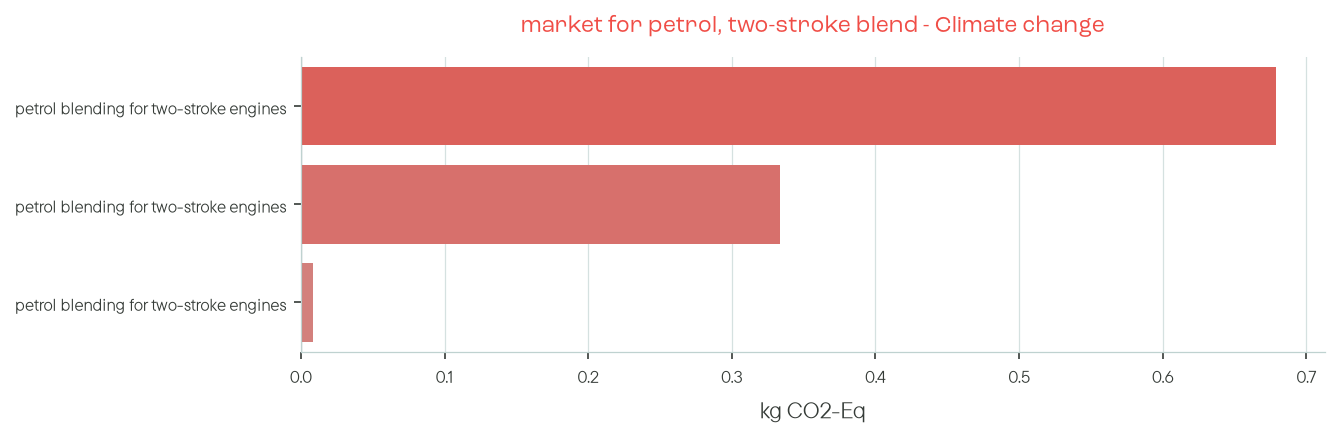

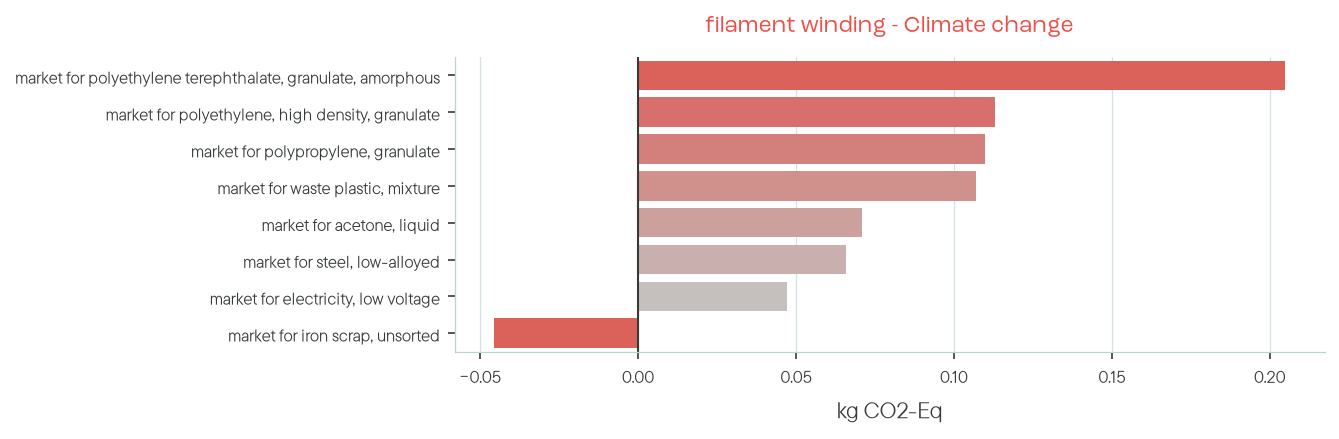

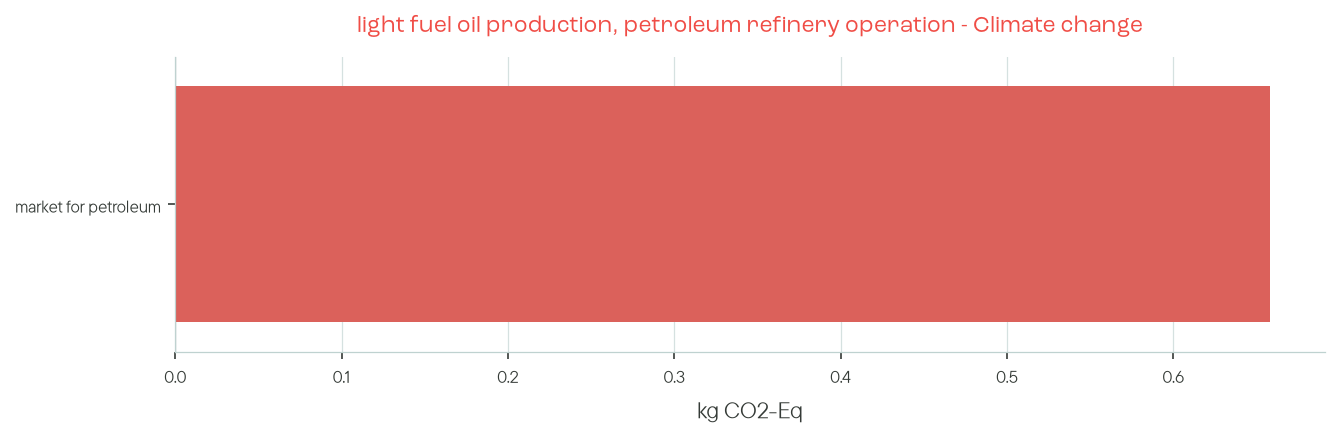

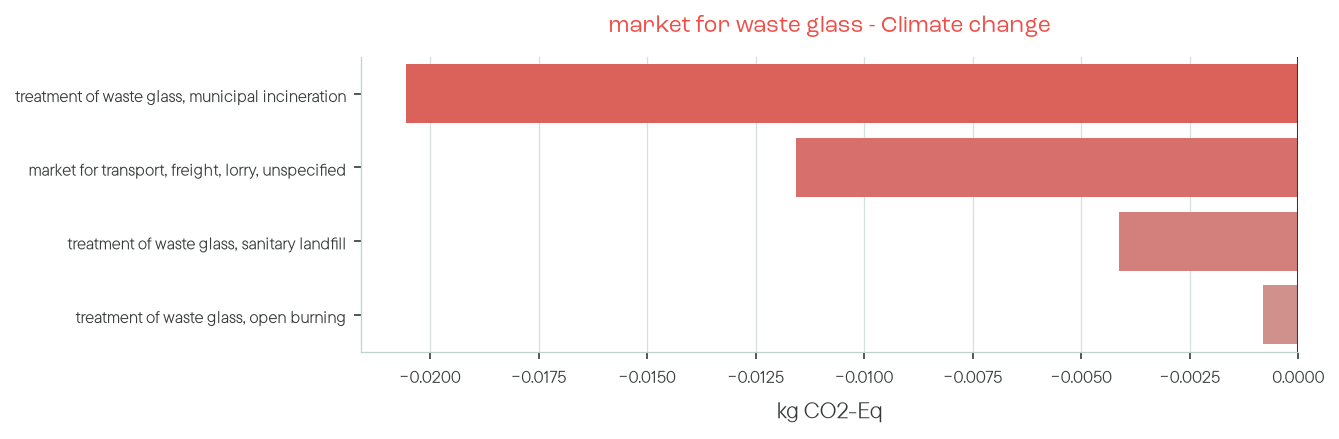

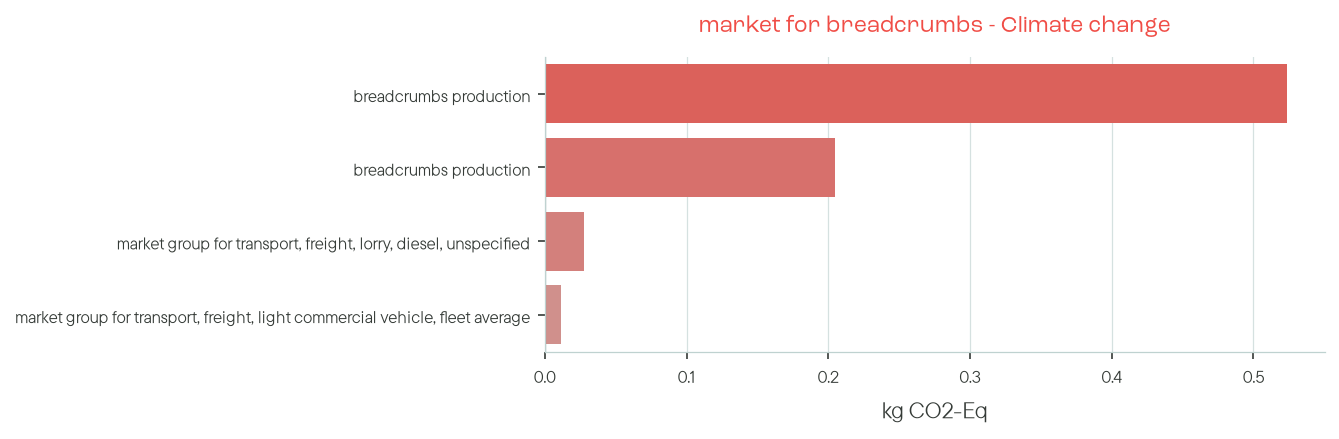

In [18]:
figures = plot_workflow_contributions(
    contribution_tables, ACTIVITIES, CATEGORIES, top_n=TOP_N,
)
for figure in figures.values():
    display(figure)
    plt.close(figure)


### Save the results (optional)

Set `SAVE_OUTPUTS = True` in Section 1 to save the tables, figures and a run record in a new results folder. The record captures activity keys, methods, settings and package versions; reproducing results also requires the same underlying databases.


In [21]:
if SAVE_OUTPUTS:
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    output_dir = REPO_ROOT / "results" / f"workflow_{run_id}"
    output_dir.mkdir(parents=True, exist_ok=False)
    activity_selection.to_csv(output_dir / "activity_selection.csv", index=False)
    scores.to_csv(output_dir / "scores.csv", index=False)
    contributions.to_csv(output_dir / "contributions.csv", index=False)
    score_checks.to_csv(output_dir / "score_checks.csv", index=False)

    figure_order = []
    for number, ((label, category), figure) in enumerate(figures.items(), start=1):
        filename = f"contribution_{number:02d}.png"
        figure.savefig(output_dir / filename, dpi=300, bbox_inches="tight")
        figure_order.append({
            "file": filename, "activity": label, "category": category,
        })

    record = {
        "run_id": run_id, "project": str(bd.projects.current),
        "foreground": FOREGROUND_NAME,
        "activities": activity_selection.to_dict(orient="records"),
        "methods": METHODS, "cutoff": CUTOFF, "max_level": 1, "top_n": TOP_N,
        "versions": {
            package: version(package)
            for package in [
                "bw2data", "bw2calc", "bw2analyzer",
                "pandas", "numpy", "matplotlib", "seaborn",
            ]
        },
        "figures": figure_order,
    }
    (output_dir / "run_record.json").write_text(
        json.dumps(record, indent=2), encoding="utf-8",
    )
    print("Saved to:", output_dir)


NameError: name 'REPO_ROOT' is not defined